# Exercises in STK-IN1150 for week 13, part 1

## What this file consists of
- [A quick warm-up](#warm-up)
- [Exercise 1](#exercise-1)
- [Exercise 2](#exercise-2)
- [Exercise 3](#exercise-3)

## A quick warm-up

In the first weeks of the course, we briefly talked about the simplest form of bootstrapping. Bootstrapping can be useful when we want more samples, because we can create artificial ones from the observed data $y = \{y_1, y_2, \ldots, y_n\}$.

We will now quickly remind ourselves of this general procedure by using a *statistic* (the mean) to construct "new data". Match each step below with the correct item.

1. Sample _ with replacement $m$ times from _
2. From that sample, compute the measure of interest _
3. Repeat this process $B$ times
4. Obtain your bootstrap sample _

Items:
- $\bar{y}^* = \frac{1}{m}\sum_{i=1}^{m} y^*_i$
- $\{y^*_1, y^*_2, \ldots, y^*_m\}$
- $\{y_1, y_2, \ldots, y_n\}$
- $\{\bar{y}_1, \bar{y}_2, \ldots, \bar{y}_B\}$

In this sheet, we set $m=n$.

## Exercise 1: Non-parametric bootstrapping

#### a)
Code the bootstrapping procedure above in using `numpy` and the information in the next code cell. Briefly comment on why we set a random seed (see Chapter 8.1 of the lecture notes).

#### b)
Report the mean, variance, and standard error of your bootstrapped sample.

#### c)
Plot a histogram of the distribution of your bootstrapped sample, and comment on its shape.

In [16]:
import numpy as np

rng = np.random.default_rng(1050)  # Set seed for reproducibility.
# Use rng. for every random generation that follows in your code (e.g., rng.choice())

y = [1, 2, 2, 3, 4, 4, 5, 5.5, 6, 6, 6, 7, 7, 8, 9]
n = len(y) # 15
m = n
B = 500

## Possible solution:

### a)

In [17]:
bootstrap_means = np.zeros(B)

for b in range(B):
    y_star = rng.choice(y, size=m, replace=True)
    bootstrap_means[b] = np.mean(y_star)

# Comment: We set a random seed to ensure reproducibility. Without it, each run would produce different random samples
# and different bootstrap results. Setting a seed allows us (and others) to recreate the exact same analysis.

### b)

In [18]:
sample_mean = np.mean(bootstrap_means)
sample_variance = np.var(bootstrap_means, ddof=1)
sample_standard_error = np.std(bootstrap_means, ddof=1)

print(f"Bootstrap mean: {sample_mean:.4f}")
print(f"Bootstrap variance: {sample_variance:.4f}")
print(f"Standard error: {sample_standard_error:.4f}")

Bootstrap mean: 5.0097
Bootstrap variance: 0.2933
Standard error: 0.5416


### c)

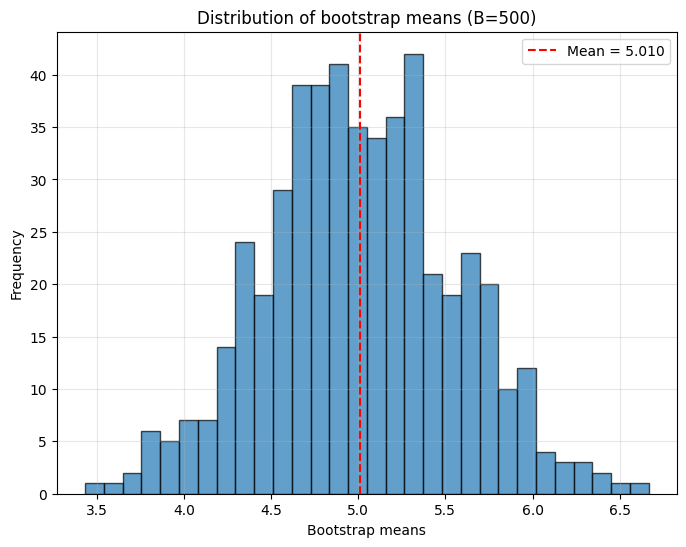

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.hist(bootstrap_means, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Bootstrap means')
plt.ylabel('Frequency')
plt.title('Distribution of bootstrap means (B=500)')
plt.axvline(sample_mean, color='red', linestyle='--', label=f'Mean = {sample_mean:.3f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Comment: The histogram appears roughly bell-shaped (approximately normal), which reflects the Central Limit Theorem.
# This makes sense because the bootstrap distribution of the sample mean is approximately normal for large B.

## Exercise 2: Parametric bootstrapping

#### 2a)
Use the histogram from 1c) to suggest a probability distribution for the data. Explain briefly why your choice seems reasonable, and estimate the needed parameter(s) from the original 15 observations.

#### 2b)
Compute the mean, variance, and standard error of your parametric bootstrap sample, just like in 1b). Are they similar to or different from those in 1b)? If they are similar, what does that tell you? If they differ, what might explain the difference and what should probably have been done differently?

#### 2c)
The terms *parametric* and *non-parametric* appear often in the field of statistics. In your own words, could you try to explain the difference between these terms? Use what you learned from Exercises 1 and 2, or from when the terms have appeared in other parts of the course so far this year. Hint: the terms relate to assumptions about "structure" and/or the data-generating process.

## Possible solution:

### a)

In [20]:
# From the histogram, the distribution appears roughly bell-shaped (symmetric, centered around 5-6).
# A reasonable choice is the Normal distribution.

# Estimate parameters from the data
mu_hat = np.mean(y)
sigma_hat = np.std(y, ddof=1)

print(f"Estimated mean: {mu_hat:.4f}")
print(f"Estimated std: {sigma_hat:.4f}")

Estimated mean: 5.0333
Estimated std: 2.3335


### b)

In [21]:
B_param = 500
bootstrap_means_param = np.zeros(B_param)

for b in range(B_param):
    y_star_param = rng.normal(loc=mu_hat, scale=sigma_hat, size=n)
    bootstrap_means_param[b] = np.mean(y_star_param)

# Compute statistics
mean_param = np.mean(bootstrap_means_param)
var_param = np.var(bootstrap_means_param, ddof=1)
se_param = np.std(bootstrap_means_param, ddof=1)

print(f"Parametric bootstrap results:")
print(f"Mean: {mean_param:.4f}")
print(f"Variance: {var_param:.4f}")
print(f"Standard error: {se_param:.4f}")

# Comparison with non-parametric (from Exercise 1b)
print(f"\nComparison with the non-parametric bootstrap from 1b):")
print(f"Mean: {sample_mean:.4f}")
print(f"Variance: {sample_variance:.4f}")
print(f"Standard error: {sample_standard_error:.4f}")

# Interpretation: The results are similar because the Normal distribution is reasonably close to the
# true distribution of our data. If they were very different, it would suggest our choice of Normal
# distribution was poor, and we should reconsider or use non-parametric bootstrap instead.

Parametric bootstrap results:
Mean: 5.0333
Variance: 0.3712
Standard error: 0.6092

Comparison with the non-parametric bootstrap from 1b):
Mean: 5.0097
Variance: 0.2933
Standard error: 0.5416


### c)

Non-parametric: Makes no assumptions about the underlying distribution. We resample directly from the observed data.
                This is more flexible and robust but requires larger samples (CLT).
                
Parametric:     Assumes the data comes from a specific distribution (e.g., Normal, Exponential).
                We estimate parameters of that distribution and generate new samples from it.
                More efficient with small samples but relies on correct model specification.


## Exercise 3

Now we will work with real data, and we will use the well-known Titanic passenger dataset. It can be obtained from [Kaggle](https://www.kaggle.com/datasets/brendan45774/test-file).

We select the columns showing whether or not passengers survived the accident, their ticket class, gender, age and number of siblings, and the price they paid for their ticket in pounds.

We give some data summaries here, which are always nice to do when introducing a new dataset to get an overview.

In [22]:
import pandas as pd

df_titanic = pd.read_csv('titanic.csv')
df_titanic = df_titanic[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp','Fare']].dropna().reset_index(drop=True)


In [23]:
df_titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  331 non-null    int64  
 1   Pclass    331 non-null    int64  
 2   Sex       331 non-null    str    
 3   Age       331 non-null    float64
 4   SibSp     331 non-null    int64  
 5   Fare      331 non-null    float64
dtypes: float64(2), int64(3), str(1)
memory usage: 15.6 KB


In [24]:
df_titanic.nunique()

Survived      2
Pclass        3
Sex           2
Age          78
SibSp         7
Fare        148
dtype: int64

In [25]:
df_titanic.head(20)

,Survived,Pclass,Sex,Age,SibSp,Fare
0,0,3,male,34.5,0,7.8292
1,1,3,female,47.0,1,7.0000
2,0,2,male,62.0,0,9.6875
3,0,3,male,27.0,0,8.6625
4,1,3,female,22.0,1,12.2875
5,0,3,male,14.0,0,9.2250
6,1,3,female,30.0,0,7.6292
7,0,2,male,26.0,1,29.0000
8,1,3,female,18.0,0,7.2292
9,0,3,male,21.0,2,24.1500


### a)
Plot a histogram of the age (*Age*), number of siblings (*SibSp*) and ticket price (*Fare*), for instance using the function ```plt.hist```.

In [26]:
import matplotlib.pyplot as plt

### b)

Here you should have observed an important feature from the data: **outliers**.

We will now see how the Bootstrap method is affected by them, so let's take the *Fare* column and calculate the mean, median, and the percentiles $25\%$ and $75\%$, as well as the variance. Note that pandas has many nice functionalities, including functions for such statistics, e.g. ```percentile```.

### c)
The mean and the median are indeed far away from each other...

Now apply bootstrap for each of the statistics we calculated. To do so you need to apply the same procedure as in the first exercise, but instead of calculating only the mean and variance, you are asked to get an estimate of the 5 statistics for each iteration. The code underneath is for you to get started.

In [27]:
n_bootstrap = 10000
fare_data = df_titanic['Fare'].values

boot_mean = []
boot_median = []
boot_p25 = []
boot_p75 = []
boot_var = []

### d)
You might observe the confidence interval of the mean is wider than the one for the median. Explain why this is.

# Possible solution:

### a)

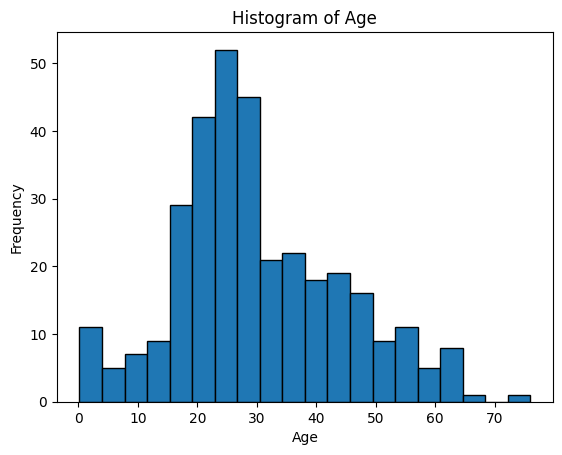

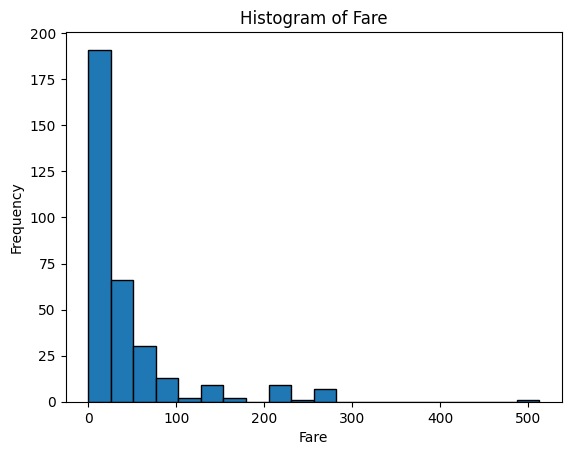

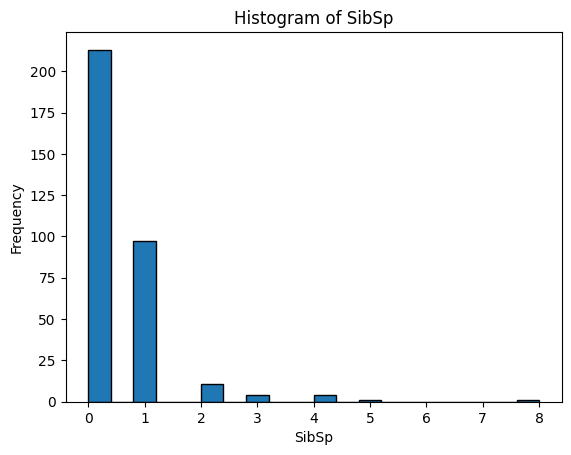

In [28]:
# a)

def PlotTitanic(df, column):
    plt.hist(df[column], bins=20, edgecolor='black')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.title(f'Histogram of {column}')
    plt.show()


PlotTitanic(df_titanic, 'Age')
PlotTitanic(df_titanic, 'Fare')
PlotTitanic(df_titanic, 'SibSp')

### b)

In [29]:
print("Mean:", df_titanic['Fare'].mean())
print("25th percentile:", df_titanic['Fare'].quantile(0.25))
print("Median:", df_titanic['Fare'].median())
print("75th percentile:", df_titanic['Fare'].quantile(0.75))
print("Variance:", df_titanic['Fare'].var())

Mean: 40.98208731117825
25th percentile: 8.05
Median: 16.0
75th percentile: 40.63335
Variance: 3748.936342379475


### c)

In [30]:
n_bootstrap = 10000
fare_data = df_titanic['Fare'].values

boot_mean = []
boot_median = []
boot_p25 = []
boot_p75 = []
boot_var = []

for _ in range(n_bootstrap):
    resample = rng.choice(fare_data, size=len(fare_data), replace=True)
    boot_mean.append(np.mean(resample))
    boot_median.append(np.median(resample))
    boot_p25.append(np.percentile(resample, 25))
    boot_p75.append(np.percentile(resample, 75))
    boot_var.append(np.var(resample))

ci_mean = np.percentile(boot_mean, [2.5, 97.5])
ci_median = np.percentile(boot_median, [2.5, 97.5])
ci_p25 = np.percentile(boot_p25, [2.5, 97.5])
ci_p75 = np.percentile(boot_p75, [2.5, 97.5])
ci_var = np.percentile(boot_var, [2.5, 97.5])

print("95% bootstrapped confidence intervals:")
print(f"Mean: {ci_mean[0]:.4f}, {ci_mean[1]:.4f}")
print(f"25th percentile: {ci_p25[0]:.4f}, {ci_p25[1]:.4f}")
print(f"Median: {ci_median[0]:.4f}, {ci_median[1]:.4f}")
print(f"75th percentile: {ci_p75[0]:.4f}, {ci_p75[1]:.4f}")
print(f"Variance: {ci_var[0]:.4f}, {ci_var[1]:.4f}")

95% bootstrapped confidence intervals:
Mean: 34.6922, 47.8665
25th percentile: 7.8958, 9.5000
Median: 13.8625, 22.0250
75th percentile: 31.3875, 55.4417
Variance: 2315.6352, 5502.7556


### d)

As the bootstrap procedure uses sampling with replacement, in some samples the outliers with the highest values will appear, whilst in others they will not. The mean is affected more heavily by outliers than the median, since the median depends only on the ordering of values, not their magnitudes like the mean does. Therefore, in each iteration, the mean will shift for outliers that appear in the sample, whilst the median will remain around the same values. This is why the mean confidence interval is wider than the interval for the median.